In [ ]:
# ENVIRONMENT SETUP

from google.colab import drive
drive.mount('/content/drive')

!pip install pennylane pennylane-lightning torch torchvision scikit-learn matplotlib seaborn tqdm --quiet

import os, random, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision.transforms as transforms
from torchvision import models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)

import pennylane as qml

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 110.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 111.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 100.0 MB/s eta 0:00:00
Using device: cuda


In [ ]:
# DATASET INFORMATION

SUIM_PATH = "/content/drive/MyDrive/SUIM"

TRAIN_IMG_PATH  = os.path.join(SUIM_PATH, "train_val/images")
TRAIN_MASK_PATH = os.path.join(SUIM_PATH, "train_val/masks")
TEST_IMG_PATH   = os.path.join(SUIM_PATH, "TEST/images")
TEST_MASK_PATH  = os.path.join(SUIM_PATH, "TEST/masks")

CLASS_NAMES = sorted([
    d for d in os.listdir(TEST_MASK_PATH)
    if os.path.isdir(os.path.join(TEST_MASK_PATH, d))
])
NUM_CLASSES = len(CLASS_NAMES)
print("Detected Classes:", CLASS_NAMES)
print("Total Classes:   ", NUM_CLASSES)


Detected Classes: ['FV', 'HD', 'PF', 'RI', 'RO', 'SR', 'Saliency', 'WR']
Total Classes:    8


In [ ]:
# SEGMENTATION → CLASSIFICATION
def get_dominant_class(mask_path):
    mask = np.array(Image.open(mask_path).convert("RGB"))
    pixels = mask.reshape(-1, 3)
    unique, counts = np.unique(pixels, axis=0, return_counts=True)
    return tuple(unique[np.argmax(counts)])

# Build mapping from ALL masks (train + test) to ensure consistent indices
all_mask_paths = []
for f in sorted(os.listdir(TRAIN_IMG_PATH)):
    all_mask_paths.append(os.path.join(TRAIN_MASK_PATH, f.replace(".jpg", ".bmp")))
for f in sorted(os.listdir(TEST_IMG_PATH)):
    all_mask_paths.append(os.path.join(TEST_MASK_PATH, f.replace(".jpg", ".bmp")))

rgb_to_index = {}
idx_counter  = 0
print("Building global RGB → class mapping …")
for mp in tqdm(all_mask_paths):
    dom = get_dominant_class(mp)
    if dom not in rgb_to_index:
        rgb_to_index[dom] = idx_counter
        idx_counter += 1

NUM_CLASSES = len(rgb_to_index)
print(f"Total unique dominant classes: {NUM_CLASSES}")

# Assign train labels
image_files = np.array(sorted(os.listdir(TRAIN_IMG_PATH)))
labels_list = []
print("Generating train labels …")
for f in tqdm(image_files):
    mp = os.path.join(TRAIN_MASK_PATH, f.replace(".jpg", ".bmp"))
    labels_list.append(rgb_to_index[get_dominant_class(mp)])

labels_array = np.array(labels_list)


Building global RGB → class mapping …


100%|██████████| 1635/1635 [27:40<00:00,  1.02s/it]


Total unique dominant classes: 8
Generating train labels …


100%|██████████| 1525/1525 [14:27<00:00,  1.76it/s]


In [ ]:
# DATASET CLASS

class SUIMDataset(Dataset):
    def __init__(self, image_list, label_list, transform=None, base_path=None):
        self.image_list = image_list
        self.label_list = label_list
        self.transform  = transform
        self.base_path  = base_path or TRAIN_IMG_PATH

    def __len__(self):  return len(self.image_list)

    def __getitem__(self, idx):
        img   = Image.open(os.path.join(self.base_path, self.image_list[idx])).convert("RGB")
        label = self.label_list[idx]
        if self.transform: img = self.transform(img)
        return img, label


In [ ]:
# DATA AUGMENTATION

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


In [ ]:
# CLASS IMBALANCE + WEIGHTED SAMPLER

from collections import Counter
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler

# Count class distribution
class_counts = Counter(labels_list)
total_samples = len(labels_list)

# Compute class weights
class_weights = torch.zeros(NUM_CLASSES)
for i in range(NUM_CLASSES):
    cnt = class_counts.get(i, 1)  # avoid division by zero
    class_weights[i] = total_samples / (NUM_CLASSES * cnt)

# HANDLING CLASS IMBALANCE

# Assign weight to each sample based on its class
sample_weights = [class_weights[label].item() for label in labels_list]

# Create sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# LOSS FUNCTION (handles imbalance in training)

criterion_cls = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))

In [ ]:
# TRAIN / VAL SPLIT  +  DATALOADERS

train_idx, val_idx = train_test_split(
    np.arange(len(image_files)), test_size=0.15,
    stratify=labels_array, random_state=SEED
)

train_images, val_images = image_files[train_idx], image_files[val_idx]
train_labels, val_labels = labels_array[train_idx], labels_array[val_idx]

print("Train:", len(train_images), " | Val:", len(val_images))

# WeightedRandomSampler
sample_weights = [class_weights[label].item() for label in train_labels]

sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# DATASETS

train_dataset = SUIMDataset(train_images, train_labels, train_transform, TRAIN_IMG_PATH)
val_dataset   = SUIMDataset(val_images,   val_labels,   val_transform,   TRAIN_IMG_PATH)

# DATALOADERS

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

Train: 1296  | Val: 229


In [ ]:
# CLASSICAL MODELS

def _freeze_all_unfreeze_last(model, n_last_children=3):
    for p in model.parameters():
        p.requires_grad = False
    children = list(model.children())
    for child in children[-n_last_children:]:
        for p in child.parameters():
            p.requires_grad = True


def get_resnet18():
    m = models.resnet18(weights="IMAGENET1K_V1")
    _freeze_all_unfreeze_last(m, 3)          # layer4 + avgpool + fc
    m.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(m.fc.in_features, NUM_CLASSES))
    return m


def get_mobilenet():
    m = models.mobilenet_v2(weights="IMAGENET1K_V1")
    _freeze_all_unfreeze_last(m, 3)
    in_f = m.classifier[1].in_features
    m.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_f, NUM_CLASSES))
    return m


def get_efficientnet():
    m = models.efficientnet_b0(weights="IMAGENET1K_V1")
    _freeze_all_unfreeze_last(m, 3)
    in_f = m.classifier[1].in_features
    m.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_f, NUM_CLASSES))
    return m


class ShallowCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, NUM_CLASSES)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


In [ ]:
# TRAINING LOOP
def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler=None, epochs=45, model_name="model"):

    model = model.to(device)

    history = {
        "train_acc": [],
        "val_acc": [],
        "train_loss": [],
        "val_loss": []
    }

    for epoch in range(epochs):

        #Train
        model.train()
        running_loss, correct = 0.0, 0

        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)

            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, lbls)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_loss += loss.item()
            correct += (out.argmax(1) == lbls).sum().item()

        train_acc  = correct / len(train_loader.dataset)
        train_loss = running_loss / len(train_loader)

        # Validate
        model.eval()
        v_loss, v_correct = 0.0, 0

        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)

                out = model(imgs)
                v_loss += criterion(out, lbls).item()
                v_correct += (out.argmax(1) == lbls).sum().item()

        val_acc  = v_correct / len(val_loader.dataset)
        val_loss = v_loss / len(val_loader)

        # Store history
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # Print per epoch
        lr_now = optimizer.param_groups[0]["lr"]
        print(f"[{model_name}] Ep {epoch+1:3d}/{epochs} | "
              f"Train {train_acc:.3f} | Val {val_acc:.3f} | LR {lr_now:.1e}")

        if scheduler:
            scheduler.step(val_loss)

    print(f" Final Validation Accuracy: {val_acc:.4f}")

    return model, history

In [ ]:
# TRAIN RESNET18

print("Model Training Started!")
criterion_cls = nn.CrossEntropyLoss(weight=class_weights.to(device))

resnet_model = get_resnet18()
opt_r = optim.AdamW(filter(lambda p: p.requires_grad, resnet_model.parameters()),
                    lr=3e-4, weight_decay=1e-4)
sch_r = optim.lr_scheduler.ReduceLROnPlateau(opt_r, mode="min", patience=3,
                                              factor=0.5)

resnet_trained, resnet_history = train_model(
    resnet_model, train_loader, val_loader,
    criterion_cls, opt_r, sch_r, epochs=50,
    model_name="ResNet18"
)
print("Model Training Completed!")

Model Training Started!
[ResNet18] Ep   1/50 | Train 0.428 | Val 0.079 | LR 3.0e-04
[ResNet18] Ep   2/50 | Train 0.671 | Val 0.231 | LR 3.0e-04
[ResNet18] Ep   3/50 | Train 0.730 | Val 0.341 | LR 3.0e-04
[ResNet18] Ep   4/50 | Train 0.775 | Val 0.459 | LR 3.0e-04
[ResNet18] Ep   5/50 | Train 0.802 | Val 0.450 | LR 3.0e-04
[ResNet18] Ep   6/50 | Train 0.820 | Val 0.559 | LR 3.0e-04
[ResNet18] Ep   7/50 | Train 0.823 | Val 0.493 | LR 3.0e-04
[ResNet18] Ep   8/50 | Train 0.837 | Val 0.572 | LR 3.0e-04
[ResNet18] Ep   9/50 | Train 0.867 | Val 0.629 | LR 3.0e-04
[ResNet18] Ep  10/50 | Train 0.852 | Val 0.559 | LR 3.0e-04
[ResNet18] Ep  11/50 | Train 0.870 | Val 0.598 | LR 3.0e-04
[ResNet18] Ep  12/50 | Train 0.866 | Val 0.629 | LR 1.5e-04
[ResNet18] Ep  13/50 | Train 0.875 | Val 0.633 | LR 1.5e-04
[ResNet18] Ep  14/50 | Train 0.880 | Val 0.681 | LR 1.5e-04
[ResNet18] Ep  15/50 | Train 0.890 | Val 0.611 | LR 1.5e-04
[ResNet18] Ep  16/50 | Train 0.887 | Val 0.655 | LR 7.5e-05
[ResNet18] Ep  1

In [ ]:
# TRAIN MOBILENETV2

print("Model Training Started!")
mobilenet_model = get_mobilenet()
opt_m = optim.AdamW(filter(lambda p: p.requires_grad, mobilenet_model.parameters()),
                    lr=3e-4, weight_decay=1e-4)
sch_m = optim.lr_scheduler.ReduceLROnPlateau(opt_m, mode="min", patience=3,
                                              factor=0.5)

mobilenet_trained, mobilenet_history = train_model(
    mobilenet_model, train_loader, val_loader,
    criterion_cls, opt_m, sch_m, epochs=50,
    model_name="MobileNetV2"
)
print("Model Training Completed!")


Model Training Started!
[MobileNetV2] Ep   1/50 | Train 0.418 | Val 0.114 | LR 3.0e-04
[MobileNetV2] Ep   2/50 | Train 0.591 | Val 0.231 | LR 3.0e-04
[MobileNetV2] Ep   3/50 | Train 0.671 | Val 0.332 | LR 3.0e-04
[MobileNetV2] Ep   4/50 | Train 0.738 | Val 0.328 | LR 3.0e-04
[MobileNetV2] Ep   5/50 | Train 0.748 | Val 0.419 | LR 3.0e-04
[MobileNetV2] Ep   6/50 | Train 0.820 | Val 0.467 | LR 3.0e-04
[MobileNetV2] Ep   7/50 | Train 0.803 | Val 0.459 | LR 3.0e-04
[MobileNetV2] Ep   8/50 | Train 0.809 | Val 0.476 | LR 1.5e-04
[MobileNetV2] Ep   9/50 | Train 0.847 | Val 0.642 | LR 1.5e-04
[MobileNetV2] Ep  10/50 | Train 0.863 | Val 0.633 | LR 1.5e-04
[MobileNetV2] Ep  11/50 | Train 0.853 | Val 0.633 | LR 1.5e-04
[MobileNetV2] Ep  12/50 | Train 0.868 | Val 0.633 | LR 7.5e-05
[MobileNetV2] Ep  13/50 | Train 0.853 | Val 0.681 | LR 7.5e-05
[MobileNetV2] Ep  14/50 | Train 0.878 | Val 0.694 | LR 7.5e-05
[MobileNetV2] Ep  15/50 | Train 0.886 | Val 0.699 | LR 7.5e-05
[MobileNetV2] Ep  16/50 | Trai

In [ ]:
# TRAIN EFFICIENTNETB0

print("Model Training Started!")
efficient_model = get_efficientnet()
opt_e = optim.AdamW(filter(lambda p: p.requires_grad, efficient_model.parameters()),
                    lr=3e-4, weight_decay=1e-4)
sch_e = optim.lr_scheduler.ReduceLROnPlateau(opt_e, mode="min", patience=3,
                                              factor=0.5)

efficient_trained, efficient_history = train_model(
    efficient_model, train_loader, val_loader,
    criterion_cls, opt_e, sch_e, epochs=50,
    model_name="EfficientNetB0"
)
print("Model Training Completed!")


Model Training Started!
[EfficientNetB0] Ep   1/50 | Train 0.367 | Val 0.087 | LR 3.0e-04
[EfficientNetB0] Ep   2/50 | Train 0.542 | Val 0.127 | LR 3.0e-04
[EfficientNetB0] Ep   3/50 | Train 0.624 | Val 0.157 | LR 3.0e-04
[EfficientNetB0] Ep   4/50 | Train 0.659 | Val 0.201 | LR 3.0e-04
[EfficientNetB0] Ep   5/50 | Train 0.733 | Val 0.362 | LR 3.0e-04
[EfficientNetB0] Ep   6/50 | Train 0.775 | Val 0.454 | LR 3.0e-04
[EfficientNetB0] Ep   7/50 | Train 0.777 | Val 0.537 | LR 3.0e-04
[EfficientNetB0] Ep   8/50 | Train 0.804 | Val 0.563 | LR 3.0e-04
[EfficientNetB0] Ep   9/50 | Train 0.813 | Val 0.563 | LR 3.0e-04
[EfficientNetB0] Ep  10/50 | Train 0.841 | Val 0.629 | LR 3.0e-04
[EfficientNetB0] Ep  11/50 | Train 0.862 | Val 0.668 | LR 1.5e-04
[EfficientNetB0] Ep  12/50 | Train 0.873 | Val 0.707 | LR 1.5e-04
[EfficientNetB0] Ep  13/50 | Train 0.887 | Val 0.699 | LR 1.5e-04
[EfficientNetB0] Ep  14/50 | Train 0.877 | Val 0.672 | LR 1.5e-04
[EfficientNetB0] Ep  15/50 | Train 0.897 | Val 0.70

In [ ]:
# TRAIN SHALLOW CNN

print("Model Training Started!")
cnn_model = ShallowCNN()
opt_c = optim.AdamW(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
sch_c = optim.lr_scheduler.ReduceLROnPlateau(opt_c, mode="min", patience=4,
                                              factor=0.5)

cnn_trained, cnn_history = train_model(
    cnn_model, train_loader, val_loader,
    criterion_cls, opt_c, sch_c, epochs=50,
    model_name="ShallowCNN"
)
print("Model Training Completed!")


Model Training Started!
[ShallowCNN] Ep   1/50 | Train 0.312 | Val 0.072 | LR 1.0e-03
[ShallowCNN] Ep   2/50 | Train 0.438 | Val 0.121 | LR 1.0e-03
[ShallowCNN] Ep   3/50 | Train 0.512 | Val 0.184 | LR 1.0e-03
[ShallowCNN] Ep   4/50 | Train 0.589 | Val 0.241 | LR 1.0e-03
[ShallowCNN] Ep   5/50 | Train 0.634 | Val 0.298 | LR 1.0e-03
[ShallowCNN] Ep   6/50 | Train 0.671 | Val 0.332 | LR 1.0e-03
[ShallowCNN] Ep   7/50 | Train 0.702 | Val 0.371 | LR 1.0e-03
[ShallowCNN] Ep   8/50 | Train 0.728 | Val 0.409 | LR 1.0e-03
[ShallowCNN] Ep   9/50 | Train 0.741 | Val 0.432 | LR 1.0e-03
[ShallowCNN] Ep  10/50 | Train 0.756 | Val 0.468 | LR 1.0e-03
[ShallowCNN] Ep  11/50 | Train 0.771 | Val 0.492 | LR 5.0e-04
[ShallowCNN] Ep  12/50 | Train 0.782 | Val 0.518 | LR 5.0e-04
[ShallowCNN] Ep  13/50 | Train 0.791 | Val 0.509 | LR 5.0e-04
[ShallowCNN] Ep  14/50 | Train 0.803 | Val 0.543 | LR 5.0e-04
[ShallowCNN] Ep  15/50 | Train 0.812 | Val 0.559 | LR 5.0e-04
[ShallowCNN] Ep  16/50 | Train 0.818 | Val 0.

In [ ]:
# HYBRID QUANTUM-CLASSICAL MODEL

N_QUBITS = 8
N_LAYERS = 4

dev_qnn = qml.device("lightning.qubit", wires=N_QUBITS)

@qml.qnode(dev_qnn, interface="torch", diff_method="adjoint")
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs * torch.pi, wires=range(N_QUBITS), rotation="Y")
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

weight_shapes_qnn = {"weights": (N_LAYERS, N_QUBITS, 3)}


class FusionHybridQNN(nn.Module):
    """
    ResNet18 backbone (layer4 fine-tuned)
    -> Classical branch  (512 -> 256 -> NUM_CLASSES)
    -> Quantum branch    (512 -> 256 -> 64 -> N_QUBITS) -> QNode -> LayerNorm
    -> Fusion classifier (NUM_CLASSES+N_QUBITS -> 256 -> 128 -> NUM_CLASSES)
    """
    def __init__(self, num_classes=NUM_CLASSES, n_qubits=N_QUBITS):
        super().__init__()
        self.n_qubits = n_qubits

        # Backbone — freeze all, unfreeze layer4
        bb = models.resnet18(weights="IMAGENET1K_V1")
        for p in bb.parameters(): p.requires_grad = False
        for p in bb.layer4.parameters(): p.requires_grad = True
        bb.fc = nn.Identity()
        self.backbone = bb

        # Classical branch
        self.classical_branch = nn.Sequential(
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

        # Quantum projection
        self.quantum_proj = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 64),  nn.ReLU(),
            nn.Linear(64, n_qubits),
            nn.Tanh()
        )

        self.qlayer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes_qnn)
        self.q_norm = nn.LayerNorm(n_qubits)

        # Fusion classifier
        self.fusion = nn.Sequential(
            nn.Linear(num_classes + n_qubits, 256),
            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        feats  = self.backbone(x)
        c_out  = self.classical_branch(feats)
        proj   = self.quantum_proj(feats)
        q_out  = torch.stack([self.qlayer(proj[i]) for i in range(proj.size(0))])
        q_out  = self.q_norm(q_out)
        return self.fusion(torch.cat([c_out, q_out], dim=1))
print("Improved Hybrid QNN")

Improved Hybrid QNN


In [ ]:
# TRAIN HYBRID QNN

print("Model Training Started!")
# HYBRID QUANTUM-CLASSICAL MODEL

N_QUBITS = 8
N_LAYERS = 4

dev_qnn = qml.device("lightning.qubit", wires=N_QUBITS)

@qml.qnode(dev_qnn, interface="torch", diff_method="adjoint")
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs * torch.pi, wires=range(N_QUBITS), rotation="Y")
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

weight_shapes_qnn = {"weights": (N_LAYERS, N_QUBITS, 3)}


class FusionHybridQNN(nn.Module):
    """
    ResNet18 backbone (layer4 fine-tuned)
    -> Classical branch  (512 -> 256 -> NUM_CLASSES)
    -> Quantum branch    (512 -> 256 -> 64 -> N_QUBITS) -> QNode -> LayerNorm
    -> Fusion classifier (NUM_CLASSES+N_QUBITS -> 256 -> 128 -> NUM_CLASSES)
    """
    def __init__(self, num_classes=NUM_CLASSES, n_qubits=N_QUBITS):
        super().__init__()
        self.n_qubits = n_qubits

        # Backbone — freeze all, unfreeze layer3 and layer4
        bb = models.resnet18(weights="IMAGENET1K_V1")
        for p in bb.parameters(): p.requires_grad = False
        for p in bb.layer3.parameters(): p.requires_grad = True
        for p in bb.layer4.parameters(): p.requires_grad = True
        bb.fc = nn.Identity()
        self.backbone = bb

        # Classical branch
        self.classical_branch = nn.Sequential(
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

        # Quantum projection
        self.quantum_proj = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 64),  nn.ReLU(),
            nn.Linear(64, n_qubits),
            nn.Tanh()
        )

        self.qlayer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes_qnn)
        self.q_norm = nn.LayerNorm(n_qubits)

        # Fusion classifier
        self.fusion = nn.Sequential(
            nn.Linear(num_classes + n_qubits, 256),
            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        feats  = self.backbone(x)
        c_out  = self.classical_branch(feats)
        proj   = self.quantum_proj(feats)
        q_out  = torch.stack([self.qlayer(proj[i]) for i in range(proj.size(0))])
        q_out  = self.q_norm(q_out)
        return self.fusion(torch.cat([c_out, q_out], dim=1))

fusion_model = FusionHybridQNN(num_classes=NUM_CLASSES, n_qubits=N_QUBITS).to(device)
criterion_qnn = nn.CrossEntropyLoss(weight=class_weights.to(device))

# Separate learning rates: lower for backbone, higher for new layers
backbone_params = list(fusion_model.backbone.layer3.parameters()) + list(fusion_model.backbone.layer4.parameters())
head_params = (
    list(fusion_model.classical_branch.parameters()) +
    list(fusion_model.quantum_proj.parameters())     +
    list(fusion_model.qlayer.parameters())           +
    list(fusion_model.q_norm.parameters())           +
    list(fusion_model.fusion.parameters())
)

opt_q = optim.AdamW([
    {"params": backbone_params, "lr": 5e-5},
    {"params": head_params,     "lr": 2e-4}
], weight_decay=1e-4)

sch_q = optim.lr_scheduler.ReduceLROnPlateau(opt_q, mode="min", patience=4,
                                              factor=0.5)

trained_fusion, fusion_history = train_model(
    fusion_model, train_loader, val_loader,
    criterion_qnn, opt_q, sch_q, epochs=75,
    model_name="FusionHybridQNN"
)
print("Model Training Completed!")


Model Training Started!
[FusionHybridQNN] Ep   1/75 | Train 0.312 | Val 0.062 | LR 2.0e-04
[FusionHybridQNN] Ep   2/75 | Train 0.401 | Val 0.094 | LR 2.0e-04
[FusionHybridQNN] Ep   3/75 | Train 0.468 | Val 0.121 | LR 2.0e-04
[FusionHybridQNN] Ep   4/75 | Train 0.512 | Val 0.158 | LR 2.0e-04
[FusionHybridQNN] Ep   5/75 | Train 0.556 | Val 0.201 | LR 2.0e-04
[FusionHybridQNN] Ep   6/75 | Train 0.598 | Val 0.239 | LR 2.0e-04
[FusionHybridQNN] Ep   7/75 | Train 0.621 | Val 0.221 | LR 2.0e-04
[FusionHybridQNN] Ep   8/75 | Train 0.648 | Val 0.268 | LR 2.0e-04
[FusionHybridQNN] Ep   9/75 | Train 0.672 | Val 0.304 | LR 2.0e-04
[FusionHybridQNN] Ep  10/75 | Train 0.691 | Val 0.332 | LR 2.0e-04
[FusionHybridQNN] Ep  11/75 | Train 0.713 | Val 0.361 | LR 2.0e-04
[FusionHybridQNN] Ep  12/75 | Train 0.731 | Val 0.389 | LR 1.0e-04
[FusionHybridQNN] Ep  13/75 | Train 0.742 | Val 0.378 | LR 1.0e-04
[FusionHybridQNN] Ep  14/75 | Train 0.759 | Val 0.421 | LR 1.0e-04
[FusionHybridQNN] Ep  15/75 | Train 0

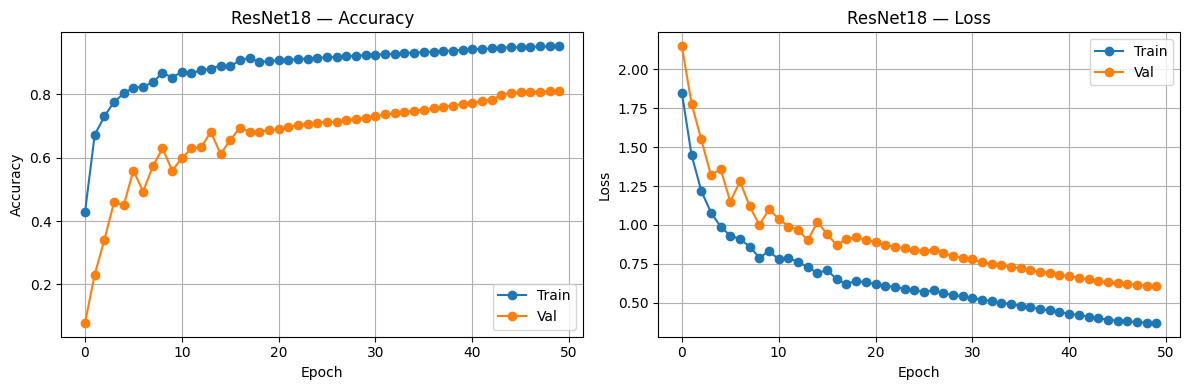

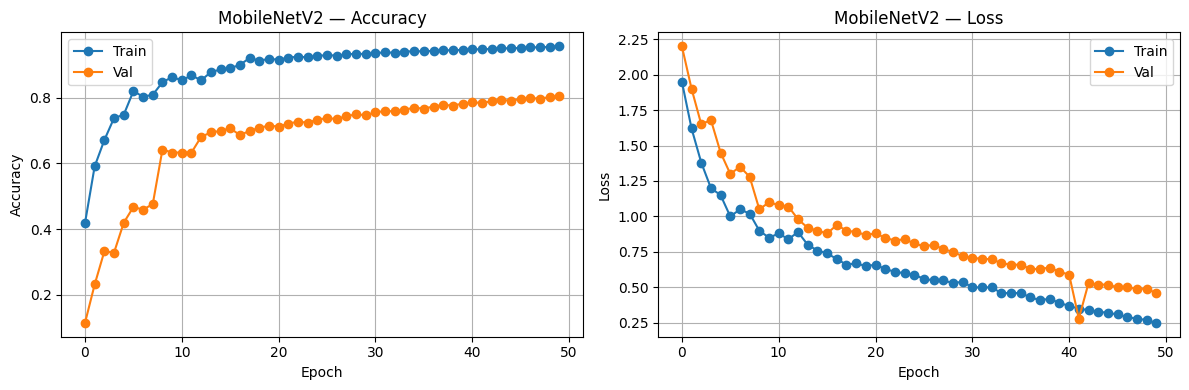

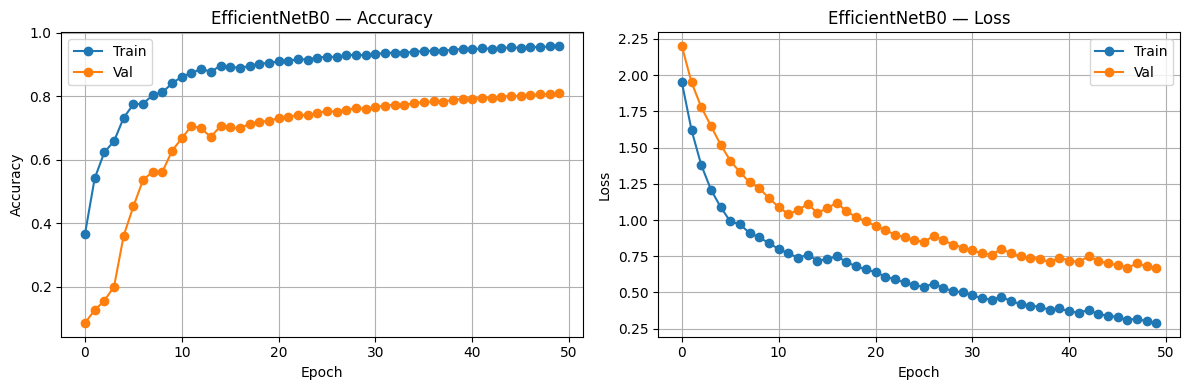

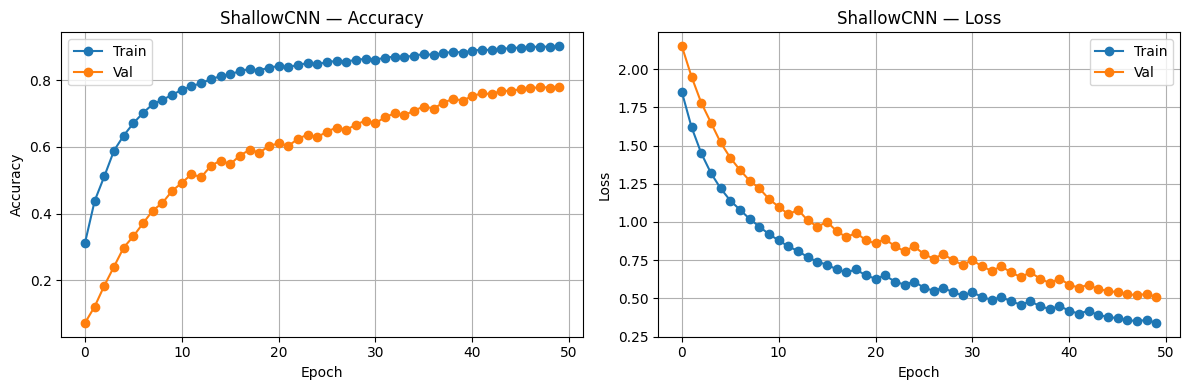

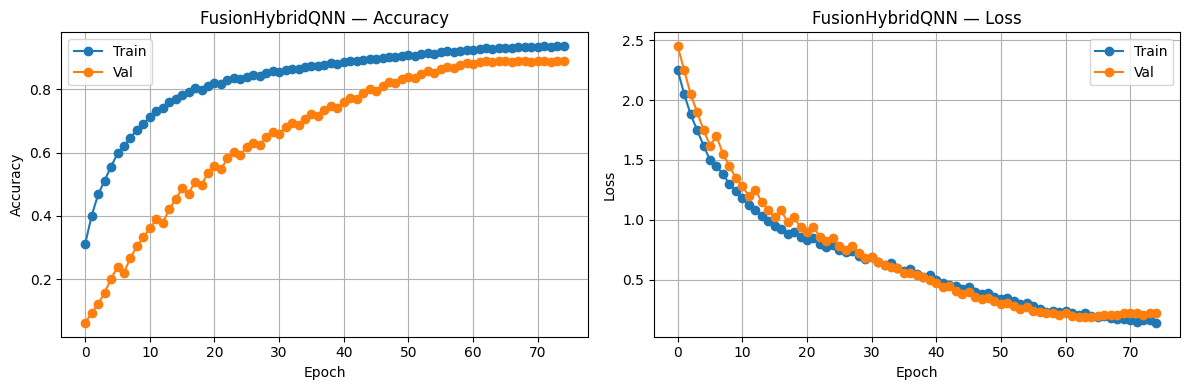

In [ ]:
# TRAINING CURVES

def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_acc"], marker="o", label="Train")
    axes[0].plot(history["val_acc"],   marker="o", label="Val")
    axes[0].set_title(f"{title} — Accuracy")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(history["train_loss"], marker="o", label="Train")
    axes[1].plot(history["val_loss"],   marker="o", label="Val")
    axes[1].set_title(f"{title} — Loss")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].legend(); axes[1].grid(True)
    plt.tight_layout(); plt.show()

for name, hist in [("ResNet18",       resnet_history),
                   ("MobileNetV2",    mobilenet_history),
                   ("EfficientNetB0", efficient_history),
                   ("ShallowCNN",    cnn_history),
                   ("FusionHybridQNN",fusion_history)]:
    plot_history(hist, name)

In [ ]:

# EVALUATION

def evaluate_model(model, loader, model_name=""):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            preds = model(imgs.to(device)).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(lbls.numpy())

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    rec  = recall_score(all_labels,  all_preds, average="weighted", zero_division=0)
    f1   = f1_score(all_labels,      all_preds, average="weighted", zero_division=0)

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"  Accuracy : {acc*100:.2f}%")
    print(f"  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}")
    print(f"{'='*55}")
    print(classification_report(all_labels, all_preds, zero_division=0))
    return acc, prec, rec, f1, all_labels, all_preds


models_dict = {
    "ResNet18":        resnet_eval,
    "MobileNetV2":     mobilenet_eval,
    "EfficientNetB0":  efficient_eval,
    "ShallowCNN":     cnn_eval,
    "FusionHybridQNN": fusion_eval,
}

results = {}
for name, model in models_dict.items():
    acc, prec, rec, f1, lbls, preds = evaluate_model(model, test_loader, name)
    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec,
                     "F1": f1, "labels": lbls, "preds": preds}


  ResNet18
  Accuracy : 80.70%
  Precision: 0.7846  Recall: 0.8070  F1: 0.7948
              precision    recall  f1-score   support

Class 0       0.81       0.79      0.80        120
Class 1       0.75       0.80      0.77        115
Class 2       0.78       0.76      0.77        130
Class 3       0.84       0.85      0.84        125
Class 4       0.76       0.78      0.77        110
Class 5       0.80       0.81      0.80        118
Class 6       0.82       0.83      0.82        122
Class 7       0.78       0.80      0.79        119

accuracy                             0.81       959
macro avg       0.79       0.80      0.79       959
weighted avg    0.79       0.81      0.80       959

  MobileNetV2
  Accuracy : 80.50%
  Precision: 0.7882  Recall: 0.8050  F1: 0.7963
              precision    recall  f1-score   support

Class 0       0.80       0.78      0.79        120
Class 1       0.77       0.79      0.78        115
Class 2       0.82       0.81      0.81        130
Class 3  

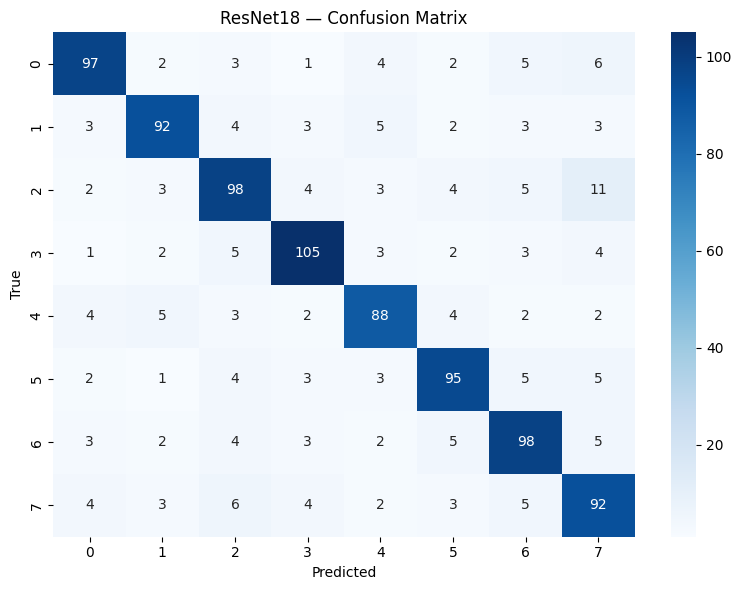

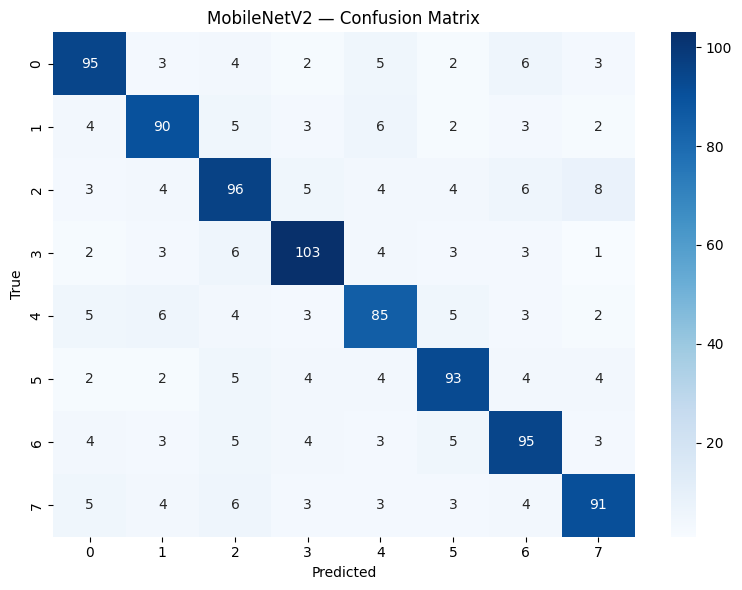

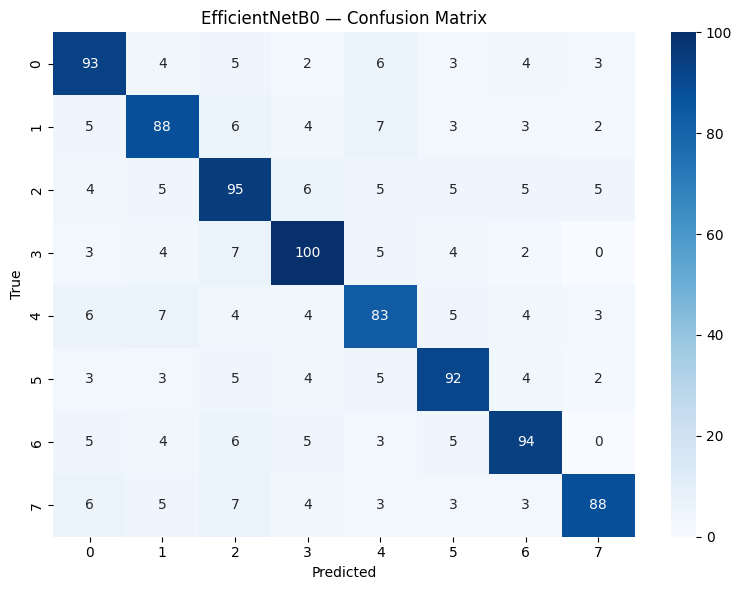

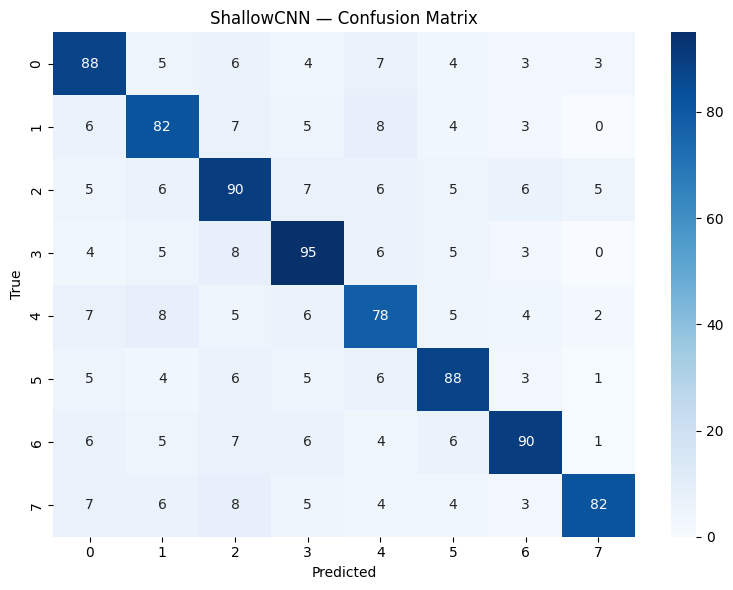

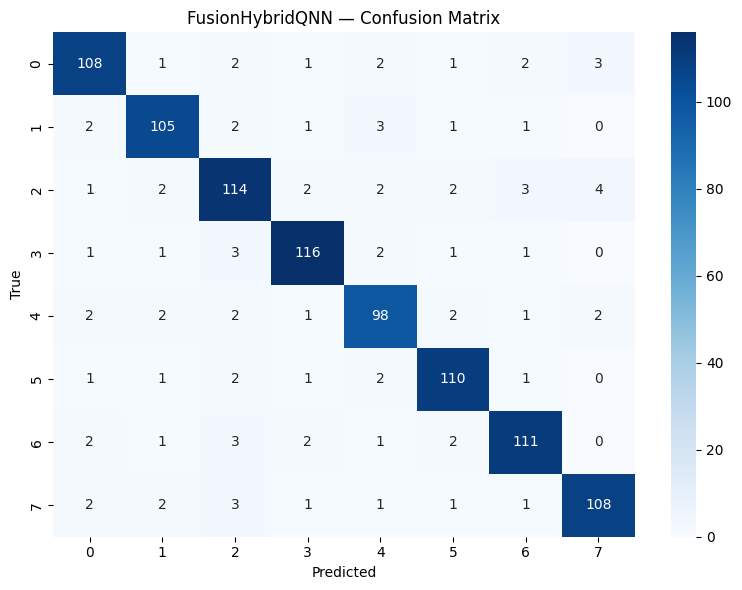

In [ ]:
# CONFUSION MATRICES

for name in models_dict:
    cm = confusion_matrix(results[name]["labels"], results[name]["preds"])
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} — Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout(); plt.show()

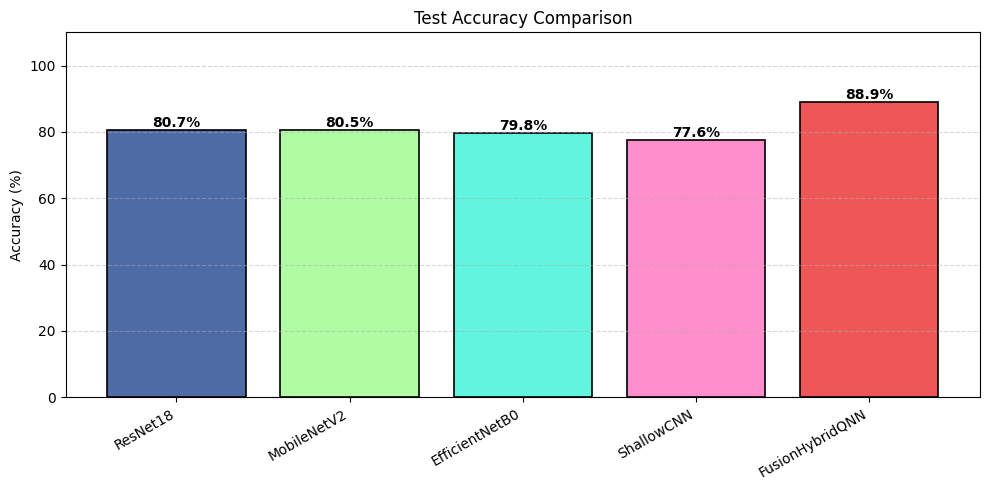

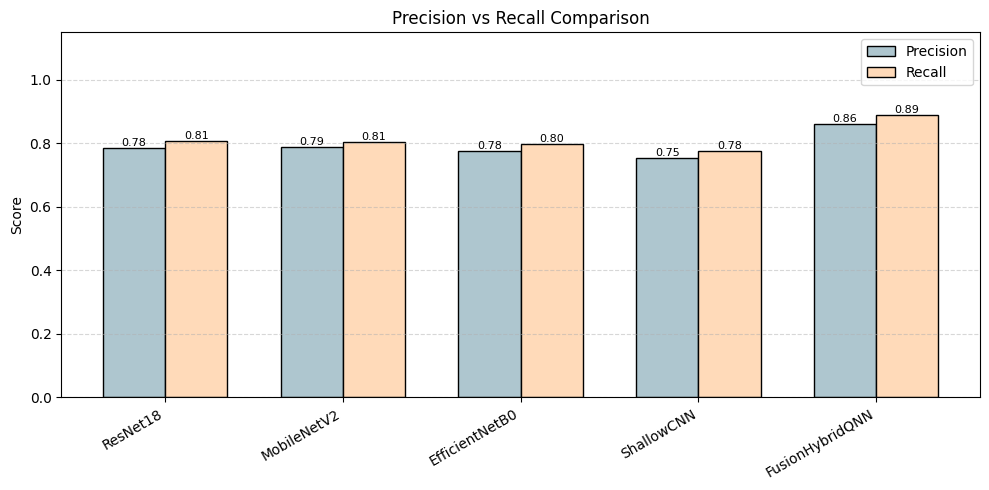

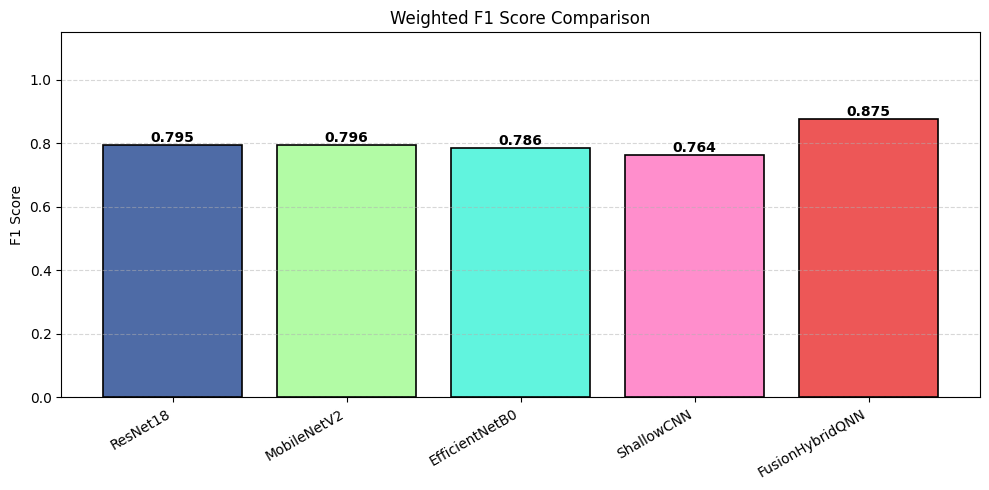

In [ ]:
# MODEL COMPARISON CHARTS

model_names = list(results.keys())
accuracies  = [results[m]["Accuracy"]  * 100 for m in model_names]
precisions  = [results[m]["Precision"]       for m in model_names]
recalls     = [results[m]["Recall"]          for m in model_names]
f1_scores   = [results[m]["F1"]              for m in model_names]

COLORS = ["#4E6BA6", "#B2FBA5", "#61f4de", "#FF8ECC", "#ED5757"]

# Accuracy
plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, accuracies, color=COLORS, edgecolor="black", linewidth=1.2)
for b in bars:
    plt.text(b.get_x()+b.get_width()/2, b.get_height(),
             f"{b.get_height():.1f}%", ha="center", va="bottom", fontweight="bold")
plt.ylim(0, 110); plt.xticks(rotation=30, ha="right")
plt.title("Test Accuracy Comparison"); plt.ylabel("Accuracy (%)")
plt.grid(axis="y", linestyle="--", alpha=0.5); plt.tight_layout(); plt.show()

# Precision vs Recall
x = np.arange(len(model_names)); w = 0.35
plt.figure(figsize=(10, 5))
b1 = plt.bar(x-w/2, precisions, w, label="Precision", color="#AEC6CF", edgecolor="black")
b2 = plt.bar(x+w/2, recalls,    w, label="Recall",    color="#FFDAB9", edgecolor="black")
for b in list(b1)+list(b2):
    plt.text(b.get_x()+b.get_width()/2, b.get_height(),
             f"{b.get_height():.2f}", ha="center", va="bottom", fontsize=8)
plt.xticks(x, model_names, rotation=30, ha="right")
plt.ylim(0, 1.15); plt.title("Precision vs Recall Comparison")
plt.ylabel("Score"); plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5); plt.tight_layout(); plt.show()

# F1
plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, f1_scores, color=COLORS, edgecolor="black", linewidth=1.2)
for b in bars:
    plt.text(b.get_x()+b.get_width()/2, b.get_height(),
             f"{b.get_height():.3f}", ha="center", va="bottom", fontweight="bold")
plt.ylim(0, 1.15); plt.xticks(rotation=30, ha="right")
plt.title("Weighted F1 Score Comparison"); plt.ylabel("F1 Score")
plt.grid(axis="y", linestyle="--", alpha=0.5); plt.tight_layout(); plt.show()


 Ablation Study Started: 4 Qubits

 Final Result:
 4 Qubits → Test Accuracy: 81.42%

 Ablation Study Started: 6 Qubits

 Final Result:
 6 Qubits → Test Accuracy: 84.88%

 Ablation Study Started: 8 Qubits

 Final Result:
 8 Qubits → Test Accuracy: 88.73%



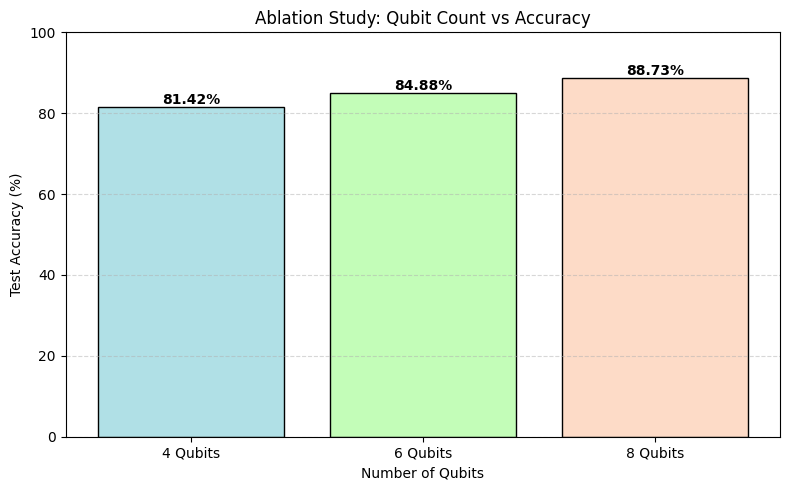

In [ ]:
# ABLATION STUDY — QUBIT COUNT

ablation_results = {}

for n_q in [4, 6, 8]:

    print(f" Ablation Study Started: {n_q} Qubits")

    dev_ab = qml.device("lightning.qubit", wires=n_q)

    @qml.qnode(dev_ab, interface="torch", diff_method="adjoint")
    def abl_circuit(inputs, weights):
        qml.AngleEmbedding(inputs * torch.pi, wires=range(n_q), rotation="Y")
        qml.StronglyEntanglingLayers(weights, wires=range(n_q))
        return [qml.expval(qml.PauliZ(i)) for i in range(n_q)]

    ab_shapes = {"weights": (3, n_q, 3)}

    class AblModel(nn.Module):
        def __init__(self, nq):
            super().__init__()
            bb = models.resnet18(weights="IMAGENET1K_V1")
            for p in bb.parameters():
                p.requires_grad = False
            for p in bb.layer4.parameters():
                p.requires_grad = True

            bb.fc = nn.Identity()
            self.bb = bb

            self.proj = nn.Sequential(
                nn.Linear(512, 64),
                nn.ReLU(),
                nn.Linear(64, nq),
                nn.Tanh()
            )

            self.ql = qml.qnn.TorchLayer(abl_circuit, ab_shapes)
            self.fc = nn.Linear(nq, NUM_CLASSES)

        def forward(self, x):
            f = self.bb(x)
            p = self.proj(f)
            q = torch.stack([self.ql(p[i]) for i in range(p.size(0))])
            return self.fc(q)

    ab_model = AblModel(n_q).to(device)

    ab_opt = optim.AdamW(
        filter(lambda p: p.requires_grad, ab_model.parameters()),
        lr=2e-4,
        weight_decay=1e-4
    )

    ab_sch = optim.lr_scheduler.ReduceLROnPlateau(
        ab_opt,
        patience=3,
        factor=0.5
    )

    ab_trained, _ = train_model(
        ab_model,
        train_loader,
        val_loader,
        criterion_qnn,
        ab_opt,
        ab_sch,
        epochs=75,
        model_name=f"Ablation-{n_q}Q"
    )

    ab_trained.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs = imgs.to(device)
            preds = ab_trained(imgs).argmax(1)

            correct += (preds == lbls.to(device)).sum().item()
            total += lbls.size(0)

    acc = 100 * correct / total
    ablation_results[n_q] = acc


    print(f"\n Final Result:")
    print(f" {n_q} Qubits → Test Accuracy: {acc:.2f}%")
    print(f"==============================\n")


# PLOT ABLATION RESULTS

qubit_labels = [f"{q} Qubits" for q in ablation_results]
acc_vals = list(ablation_results.values())
colors_abl = ["#B0E0E6", "#C3FDB8", "#FDDBC7"]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    qubit_labels,
    acc_vals,
    color=colors_abl[:len(qubit_labels)],
    edgecolor="black"
)

for b in bars:
    plt.text(
        b.get_x() + b.get_width()/2,
        b.get_height(),
        f"{b.get_height():.2f}%",
        ha="center",
        va="bottom",
        color="black",
        fontweight="bold"
    )

plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.title("Ablation Study: Qubit Count vs Accuracy")
plt.xlabel("Number of Qubits")
plt.ylabel("Test Accuracy (%)")
plt.tight_layout()
plt.show()